An illustration of potential biases in
the determination of RV parameters.

In [1]:
%reset -f

import numpy as np
import scipy.optimize as SciOpt
from numpy import random as rnd
from numpy import linalg as LA
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({'font.size': 18})

In [2]:
### First, understand how Python computes Standard Deviation ###
### Use "data" from Lab 06                                   ###

year = np.array([  1,  2,  3,  4,  5])
joke = np.array([ 12, 18, 33, 27, 39])
rate = np.array([5.1,4.1,3.8,3.3,3.6])
N    = len(joke)

avg_joke = np.mean(joke)
sig_joke = np.std(joke)

print("np.mean(joke) =",avg_joke)
print("np.std(joke)  =",sig_joke)

np.mean(joke) = 25.8
np.std(joke)  = 9.785703858180053


In [3]:
### Compare np.cov and complete "by hand" calculation of sigma ###

covariance    = np.cov(joke,rate)
sig_joke_cov  = np.sqrt(covariance[0,0])

var_joke_hand = np.sum((joke-avg_joke)**2)/(N-1)
sig_joke_hand = np.sqrt(var_joke_hand)

print("calculations of standard deviation:")
print("-----------------------------------")
print("np.std result     = ",sig_joke)
print("np.cov result     = ",sig_joke_cov)
print("calculate by hand = ",sig_joke_hand)

calculations of standard deviation:
-----------------------------------
np.std result     =  9.785703858180053
np.cov result     =  10.940749517286282
calculate by hand =  10.940749517286282


We have shown that np.cov applies the Bessel correction, np.std does not! 

In [4]:
N = 100                             # samples per experiment

xmin = 0.2
xmax = 0.8

Nexp = 100000                      # number of experiments

beta = 0.5                         # ground truth exponential parameter

Acc1 = np.zeros(Nexp)              # decay constant from mean 
Acc2 = np.zeros(Nexp)              # decay constant from std dev (no Bessel)
Acc3 = np.zeros(Nexp)              # decay constant from std dev (w/ Bessel)

In [5]:
for ii in np.linspace(1,Nexp,Nexp,dtype=int):
    
    # Generate N exponential r.v.'s
    rvvec=rnd.exponential(beta, N)
    
    #1. Estimate decay constant using mean
    Acc1[ii-1] = np.mean(rvvec)
    
    #2. Estimate decay constant using standard deviation
    Acc2[ii-1] = np.std(rvvec)    
    
    #3. Estimate decay constant using standard deviation with Bessel's Correction
    
    rvavg = np.mean(rvvec)
    rvtmp = np.sum((rvvec-rvavg)**2)/(N-1)
    Acc3[ii-1] = np.sqrt(rvtmp)    

N:  100
average mean    : 0.5003614677870432
average stdv    : 0.493278908972689
average stdv (B): 0.4957639569873592


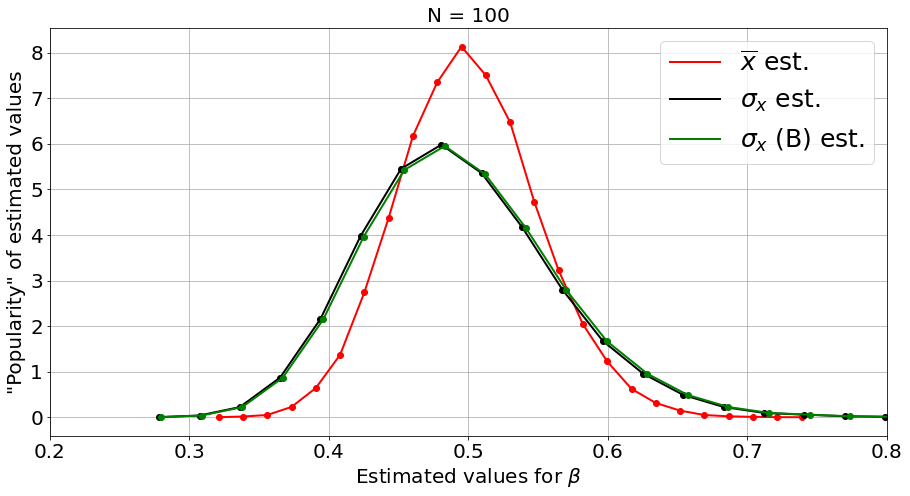

In [6]:
# plot results

fig = plt.figure(figsize=(15,7.5))

# estimation by mean

vals, binedges = np.histogram(Acc1,25,density=True) 
bincenters=(binedges[1:]+binedges[:-1])/2
plt.plot(bincenters,vals,'r',label='$\overline{x}$ est.', linewidth=2)
plt.plot(bincenters,vals,'r.', markersize=12)

# estimation by standard deviation

vals, binedges = np.histogram(Acc2,25,density=True) 
bincenters=(binedges[1:]+binedges[:-1])/2
plt.plot(bincenters,vals,'k',label='$\sigma_x$ est.', linewidth=2)
plt.plot(bincenters,vals,'k.', markersize=12)

# estimation by standard deviation w/ Bessel correction

vals, binedges = np.histogram(Acc3,25,density=True) 
bincenters=(binedges[1:]+binedges[:-1])/2
plt.plot(bincenters,vals,'g',label='$\sigma_x$ (B) est.', linewidth=2)
plt.plot(bincenters,vals,'g.', markersize=12)

print("N: ",N)
print("average mean    :",np.mean(Acc1))
print("average stdv    :",np.mean(Acc2))
print("average stdv (B):",np.mean(Acc3))

plt.xlim([xmin, xmax])

plt.legend(fontsize=25)
plt.legend(fontsize=25)
plt.xticks(size = 20)
plt.yticks(size = 20)

plt.xlabel('Estimated values for $\\beta$', fontsize=20)
plt.ylabel('"Popularity" of estimated values', fontsize=20)
plt.grid()

titlename = "N = "+str(N)
plt.title(titlename,fontsize=20)

figname = str(N)+".png"
plt.savefig(figname)
plt.show()

In [7]:
### the calculations above are performed for ###
### varying numbers of samples, and the      ###
### following data are obtained:             ###

Nsamp    = np.array([2, 5, 10, 20, 40, 60, 80, 100])
avg_mean = np.array([0.4995, 0.4996, 0.4990, 0.5006, 0.5003, 0.4999, 0.4999, 0.4999])
avg_stdv = np.array([0.2503, 0.3862, 0.4374, 0.4677, 0.4825, 0.4881, 0.4911, 0.4927])
avg_stdb = np.array([0.3543, 0.4323, 0.4620, 0.4791, 0.4891, 0.4920, 0.4941, 0.4954])


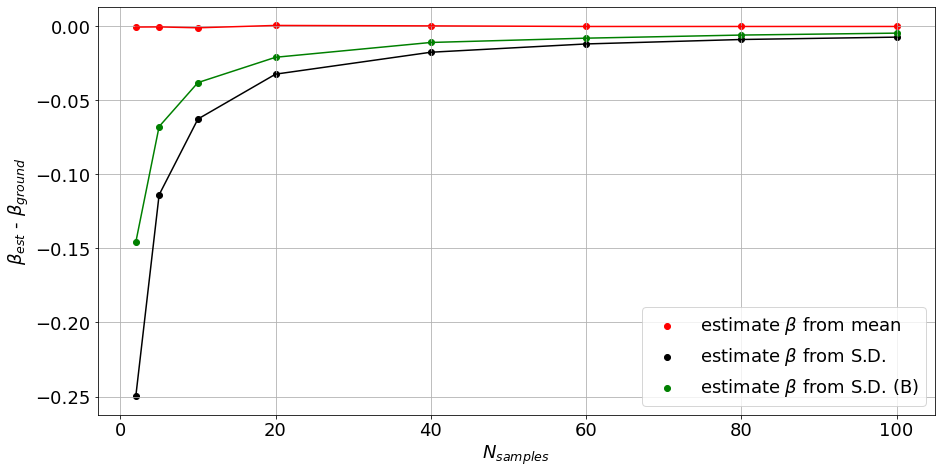

In [8]:
### plot these ### 

fig = plt.figure(figsize=(15,7.5))
plt.scatter(Nsamp,avg_mean-beta,c='r',label="estimate $\\beta$ from mean")
plt.scatter(Nsamp,avg_stdv-beta,c='k',label="estimate $\\beta$ from S.D.")
plt.scatter(Nsamp,avg_stdb-beta,c='g',label="estimate $\\beta$ from S.D. (B)")

plt.plot(Nsamp,avg_mean-beta,c='r')
plt.plot(Nsamp,avg_stdv-beta,c='k')
plt.plot(Nsamp,avg_stdb-beta,c='g')

plt.legend(loc="lower right")
plt.grid()
plt.xlabel("$N_{samples}$")
plt.ylabel("$\\beta_{est}$ - $\\beta_{ground}$")

plt.show()